# Agents and Tools
This notebook is my exploration of the [Add tools](https://langchain-ai.github.io/langgraph/tutorials/get-started/2-add-tools/) tutorial by Langgraph. It follows the [previous notebook](./simple_chatbot_langgraph.ipynb) that built a simple chatbot. We provide the LLM with a web search tool powered by the Tavily Web Search API so we need an API key to execute the tool.

## Required packages
* `langchain[anthropic]`
* `langchain-tavily`
* `langgraph`
* `langsmith`

In [1]:
import json
from typing import Annotated
from typing_extensions import TypedDict

from IPython.display import Image, display, Markdown
from langchain_core.messages import BaseMessage, ToolMessage
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
# Load Anthropic and Tavily API keys
# The `secrets.env` file is expected to have the following lines:
# ANTHROPIC_API_KEY="sk-ant-xxxxx"
# TAVILY_API_KEY="tvly-dev-xxxxx"
from dotenv import load_dotenv
load_dotenv("../../secrets.env")

True

## Tool definition
First, we define the search tool and test it. Since the intention of web search is to look for information that the model will likely not have encountered during its training process, we ask it a question about an event that happened in August, 2025.

In [3]:
search_tool = TavilySearch(max_results=2)
tools = [search_tool]
search_tool.invoke("Who won the Community Shield in English football in 2025?")

{'query': 'Who won the Community Shield in English football in 2025?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.cpfc.co.uk/news/announcement/crystal-palace-2025-fa-community-shield-winners/',
   'title': 'Crystal Palace – 2025 FA Community Shield winners! - News',
   'content': '# Crystal Palace – 2025 FA Community Shield winners! Crystal Palace Football Club have won the 2025 FA Community Shield at Wembley! Following on from our FA Cup final victory in May, Oliver Glasner’s Eagles made it back-to-back trophies on visits to Wembley, with a penalty shoot-out win over Premier League winners Liverpool. > CRYSTAL PALACE WIN THE COMMUNITY SHIELD! > CRYSTAL PALACE ARE THE 2025 COMMUNITY SHIELD WINNERS ❤️💙 pic.twitter.com/dXhwOVGbSZ > — Crystal Palace F.C. * The Numbers: Crystal Palace win the 2025 Community Shield The Numbers: Crystal Palace win the 2025 Community Shield The Numbers: Crystal Palace win the 2025 Community Shield  * Commun

## Graph definition
Having ensured that the web search tool functions as expected, we now define a chatbot graph with provides the LLMs with the list of tools it has access to.

The `bind_tools()` method of the `llm` object provides information about tools i.e. functions that the LLM can choose to call in order to answer the question. If we wish to force the LLM to select a tool to call, we can pass the `tool_choice` argument as `"any"` in the `bind_tools()` method. If we want to LLM to use a specific tool, we can pass the name of the tool instead (for example, `tool_choice="search_tool"`).

In [4]:
llm = init_chat_model("anthropic:claude-sonnet-4-0")

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# Tell the LLM the tools it can call
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

## Create function to run tools
Next, we define a class `BasicToolNode` to execute all the tools specified by the LLM in its output. If the LLM deems it necessary, it will return an output with one or more tool calls and their respective arguments. 

We initialise the class with the list of available tools. The `__call__` method is a special (dunder) method that allows an instance/object of a class to be called as if it were a function. It expects a dictionary as input which is the data type of the `State` class. This class defines the schema of the graph and as defined above, it contains the `messages` key.

In [5]:
class BasicToolNode:
    """A node that runs tools required in the last AI Message"""
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No messages found in inputs")
        
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"]
                )
            )

        return {"messages": outputs}
    
tool_node = BasicToolNode(tools)
graph_builder.add_node("tools", tool_node)

## Define conditional edges
A conditional edge is a special construct in Langgraph that allows us to route the graph to a node based on the output of the LLM. In the example below, if the message from the LLM contains the attribute `tool_calls`, the graph transitions to calling the tools using the `tools` node defined above using `BasicToolNode`. In case of no tool calls in the LLM response, the graph finished execution.

In [6]:
def route_tools(state: State):
    """
    Use in the conditional edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    else:
        return END
    
# The `route_tools` function returns "tools" if the chatbot asks to use a tool, 
# and "END" if it is fine directly responding. This conditioning routing
# defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary helps the graph interpret the condition's outputs
    # as a specific node. It defaults to the identity function but if we want to 
    # use a node named something else apart from "tools", we can update the value 
    # of the dictionary to something else e.g. "tools": "my_tools". Thus, in
    # the dictionary below, the key is the output of the `route_tools` function
    # and the value is the name of the node to be called.
    {"tools": "tools", END: END}
)

# Anytime a tool is called, we return to the chatbot to decide the next step.
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

## Visualise graph

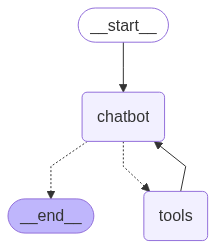

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test the chatbot
Let us now test the chatbot with the same query that we asked above.

In [27]:
def display_text_response(text: str) -> None:
    """Display a Markdown-formatted assistant response."""
    display(Markdown("**Assistant:**\n" + text))

def display_tool_use(tool_info: dict) -> None:
    """Display information about a tool usage in Markdown format.
    
    Args:
        tool_info (dict): Dictionary containing tool usage details.
    """
    tool_name = tool_info.get("name", "")
    tool_input = tool_info.get("input", {})
    query = tool_input.get("query", "")
    topic = tool_input.get("topic", "")
    search_depth = tool_input.get("search_depth", "")
    display(Markdown(
        f"**Tool Use:** `{tool_name}`\n\n"
        f"- **Query:** `{query}`\n"
        f"- **Topic:** `{topic}`\n"
        f"- **Search Depth:** `{search_depth}`\n"
    ))

def display_search_results(results: list) -> None:
    """Display a list of search results in Markdown format.
    
    Args:
        results (list): List of dictionaries containing search result details.
    """
    for result in results:
        url = result.get("url", "")
        title = result.get("title", "")
        score = result.get("score", "")
        published_date = result.get("published_date", "")
        display(Markdown(
            f"**Search Result:**\n"
            f"- **Title:** [{title}]({url})\n"
            f"- **Score:** `{score}`\n"
            f"- **Published Date:** `{published_date}`\n"
        ))

def handle_latest_message(latest_message: object) -> None:
    """Handle and display the latest message from the graph event.
    
    Args:
        latest_message (object): The latest message, can be a list or string.
    """
    if isinstance(latest_message, list):
        for v in latest_message:
            if v["type"] == "text":
                display_text_response(v["text"])
            elif v["type"] == "tool_use":
                display_tool_use(v)
            else:
                raise ValueError("Message type is neither 'text' nor 'tool_use'")
    elif isinstance(latest_message, str):
        try:
            results = json.loads(latest_message)["results"]
            display_search_results(results)
        except json.JSONDecodeError:
            display_text_response(latest_message)
    else:
        raise ValueError("Latest message is neither of 'str' or 'list'")

def stream_graph_updates(user_input: str) -> None:
    """Stream updates from the graph for a given user input and display responses.
    
    Args:
        user_input (str): The user's input message.
    """
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            latest_message = value["messages"][-1].content
            handle_latest_message(latest_message)

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    display(Markdown(f"**Question**:\n{user_input}\n"))
    stream_graph_updates(user_input)

**Question**:
Who won the Community Shield in English football in 2025?


**Assistant:**
I'll search for information about the 2025 Community Shield winner in English football.

**Tool Use:** `tavily_search`

- **Query:** `Community Shield 2025 winner English football`
- **Topic:** `news`
- **Search Depth:** `basic`


**Search Result:**
- **Title:** [Stats: Salah up to fourth, Messi's 30, Kane's 2nd and Bayern's 11th - ESPN](https://www.espn.com/soccer/story/_/id/46005162/stats-mohamed-salah-fourth-lionel-messi-30-harry-kane-2nd-bayern-munich-11th)
- **Score:** `0.32254782`
- **Published Date:** `Mon, 18 Aug 2025 05:03:00 GMT`


**Search Result:**
- **Title:** [2025 English Premier League Predictions: Top 6 Rankings - FOX Sports](https://www.foxsports.com/stories/soccer/2025-english-premier-league-predictions-top-6-rankings)
- **Score:** `0.2131973`
- **Published Date:** `Fri, 15 Aug 2025 14:16:51 GMT`


**Assistant:**
The search didn't return specific information about the 2025 Community Shield winner. Let me try a more targeted search.

**Tool Use:** `tavily_search`

- **Query:** `"Community Shield 2025" "FA Community Shield" winner result`
- **Topic:** `news`
- **Search Depth:** ``


**Search Result:**
- **Title:** [Crystal Palace 2-2 Liverpool (3-2 pens): Henderson heroics secure Community Shield win - The New York Times](https://www.nytimes.com/athletic/6545064/2025/08/10/crystal-palace-liverpool-community-shield-result-analysis/)
- **Score:** `0.8588255`
- **Published Date:** `Sun, 10 Aug 2025 16:32:04 GMT`


**Search Result:**
- **Title:** [What we learned as Palace beat Liverpool to lift the Community Shield - Premier League](https://www.premierleague.com/en/news/4373220/community-shield-analysis-as-crystal-palace-beat-liverpool-on-penalties-at-wembley)
- **Score:** `0.70944256`
- **Published Date:** `Sun, 10 Aug 2025 19:03:04 GMT`


**Assistant:**
Based on the search results, I can provide you with the answer:

**Crystal Palace won the 2025 Community Shield** in English football. They defeated Liverpool 2-2 in regular time and then won 3-2 on penalties at Wembley Stadium on August 10, 2025.

The match was between Crystal Palace (as FA Cup winners) and Liverpool (as Premier League champions). After a 2-2 draw in regular time, Crystal Palace secured victory in the penalty shootout, with goalkeeper Dean Henderson playing a heroic role in the shootout, similar to his previous penalty-saving performances.

## Use pre-built functions
Langgraph comes pre-built with the following function to make it easier to call tools:
* The `ToolNode` class implements the functionality of calling the tools returned by the LLM.
* The `tools_condition` function takes care of routing the graph to tool calling if the LLM returns one or mode tool calls in its output.

In [28]:
graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
graph = graph_builder.compile()

In [30]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            latest_message = value["messages"][-1].content
            handle_latest_message(latest_message)

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    display(Markdown(f"**Question**:\n{user_input}\n"))
    stream_graph_updates(user_input)

**Question**:
Who won the Community Shield in English football in 2025?


**Assistant:**
I'll search for information about the 2025 Community Shield winner in English football.

**Tool Use:** `tavily_search`

- **Query:** `Community Shield 2025 winner English football`
- **Topic:** `news`
- **Search Depth:** `basic`


**Search Result:**
- **Title:** [Stats: Salah up to fourth, Messi's 30, Kane's 2nd and Bayern's 11th - ESPN](https://www.espn.com/soccer/story/_/id/46005162/stats-mohamed-salah-fourth-lionel-messi-30-harry-kane-2nd-bayern-munich-11th)
- **Score:** `0.32254782`
- **Published Date:** `Mon, 18 Aug 2025 05:03:00 GMT`


**Search Result:**
- **Title:** [2025 English Premier League Predictions: Top 6 Rankings - FOX Sports](https://www.foxsports.com/stories/soccer/2025-english-premier-league-predictions-top-6-rankings)
- **Score:** `0.2131973`
- **Published Date:** `Fri, 15 Aug 2025 14:16:51 GMT`


**Assistant:**
The search results don't specifically mention the Community Shield winner for 2025. Let me search more specifically for the FA Community Shield 2025.

**Tool Use:** `tavily_search`

- **Query:** `FA Community Shield 2025 match result winner`
- **Topic:** `news`
- **Search Depth:** `advanced`


**Search Result:**
- **Title:** [Crystal Palace 2-2 Liverpool (3-2 pens): Henderson heroics secure Community Shield win - The New York Times](https://www.nytimes.com/athletic/6545064/2025/08/10/crystal-palace-liverpool-community-shield-result-analysis/)
- **Score:** `0.8909888`
- **Published Date:** `Sun, 10 Aug 2025 16:32:04 GMT`


**Search Result:**
- **Title:** [What is the FA Community Shield? History, past winners of English football game at Wembley - sportingnews.com](https://www.sportingnews.com/au/football/news/community-shield-history-past-winners-football/5d8cf27e43951d9048741190)
- **Score:** `0.44174582`
- **Published Date:** `Sun, 10 Aug 2025 13:00:01 GMT`


**Assistant:**
Perfect! Based on the search results, I can now provide you with the answer about the 2025 Community Shield winner.

**Crystal Palace won the 2025 FA Community Shield**, defeating Liverpool 3-2 on penalties after a 2-2 draw at Wembley Stadium on August 10, 2025.

The match was entertaining with goals from Liverpool debutants Hugo Ekitike and Jeremie Frimpong, while Crystal Palace scored through a Jean-Philippe Mateta penalty (after Ismaila Sarr was fouled by Virgil van Dijk) and another equalizer. After the match ended 2-2 in regular time, Crystal Palace won the trophy in a penalty shootout with goalkeeper Henderson playing a heroic role.

This was Crystal Palace's first Community Shield victory, as they qualified for the match by winning the FA Cup in the previous season.